In [1]:
# =============================================================================
# CELLULE 1 — Imports communs
# =============================================================================

import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import (
    CamembertTokenizer,
    CamembertModel,
    CamembertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW # Corrected import path for AdamW
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving fr_EOHL_Reddit_prediction.xlsx to fr_EOHL_Reddit_prediction.xlsx
User uploaded file "fr_EOHL_Reddit_prediction.xlsx" with length 3233408 bytes


In [3]:
# =============================================================================
# CELLULE 3 — Chargement des données
# =============================================================================

df = pd.read_excel('fr_EOHL_Reddit_prediction.xlsx')

In [5]:
# =============================================================================
# CELLULE 4 — Imports & configuration
# =============================================================================
from collections import Counter

# Affichage inline dans Colab
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 50)

print("✅ Imports OK")

✅ Imports OK


In [6]:
# =============================================================================
# CELLULE 5 — Exploration initiale (shape, types, aperçu)
# =============================================================================

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}\n")

print("--- Types ---")
print(df.dtypes, "\n")

print("--- Aperçu (5 premières lignes) ---")
display(df.head())

print("--- Statistiques descriptives ---")
display(df.describe(include='all'))

Shape : (20000, 3)
Colonnes : ['text', 'Perspective_probability', 'Perspective_label']

--- Types ---
text                        object
Perspective_probability    float64
Perspective_label            int64
dtype: object 

--- Aperçu (5 premières lignes) ---


,text,Perspective_probability,Perspective_label
0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",0.041915,0
1,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",0.008671,0
2,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",0.110887,0
3,Non pas de problème de ce côté là heureusement !,0.004021,0
4,"&gt;Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais t...",0.254629,0


--- Statistiques descriptives ---


,text,Perspective_probability,Perspective_label
count,19498,19999.000000,20000.000000
unique,19257,NaN,NaN
top,Tu ne trouves pas la réponse à ta question ici ? Tu la trouveras peut-être sur r/askfrance\n\nNot finding the answer...,NaN,NaN
freq,55,NaN,NaN
mean,NaN,0.092475,0.028400
std,NaN,0.124216,2.011565
min,NaN,0.000251,0.000000
25%,NaN,0.012378,0.000000
50%,NaN,0.034984,0.000000
75%,NaN,0.114090,0.000000


=== Valeurs manquantes ===
text                       502
Perspective_probability      1
dtype: int64

=== Distribution des labels ===
Perspective_label
0      19715
1        284
284        1
Name: count, dtype: int64

=== Lignes avec label aberrant ===


,text,Perspective_probability,Perspective_label
19999,NaN,NaN,284


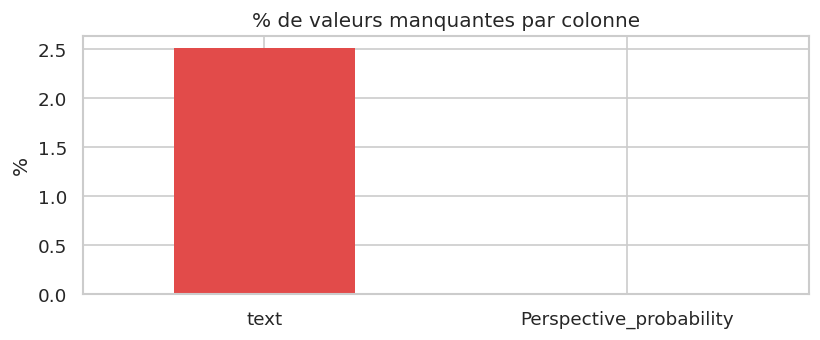

In [7]:
# =============================================================================
# CELLULE 6 — Valeurs manquantes & anomalies de label
# =============================================================================

print("=== Valeurs manquantes ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Distribution des labels ===")
print(df['Perspective_label'].value_counts().sort_index())

# Détection de labels aberrants (valeurs hors {0, 1})
labels_valides = {0, 1}
aberrants = df[~df['Perspective_label'].isin(labels_valides)]
print(f"\n=== Lignes avec label aberrant ===")
display(aberrants)

# Visualisation des manquants
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='#E24B4A', edgecolor='none')
ax.set_title('% de valeurs manquantes par colonne')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# =============================================================================
# CELLULE 7 — Analyse des doublons & messages de bots
# =============================================================================

# Doublons
n_dupl = df.duplicated(subset='text').sum()
print(f"Doublons (texte exact) : {n_dupl}")

print("\nTop 5 textes les plus répétés :")
display(df['text'].value_counts().head(5).reset_index().rename(
    columns={'text': 'texte', 'count': 'occurrences'}))

# Bots
BOT_PATTERN = r'(I am a bot|AutoModérateur|AutoModerator|performed automatically|bot)'
df['is_bot'] = df['text'].fillna('').astype(str).str.contains(BOT_PATTERN, case=False, regex=True)
print(f"\nMessages de bots détectés : {df['is_bot'].sum()}")
display(df[df['is_bot']][['text']].head(3))

Doublons (texte exact) : 742

Top 5 textes les plus répétés :


,texte,occurrences
0,Tu ne trouves pas la réponse à ta question ici ? Tu la trouveras peut-être sur r/askfrance\n\nNot finding the answer...,55
1,AutoModérateur est profondément désolé de t'informer que ton compte est trop jeune ou que tu n'as pas assez de karma...,18
2,"Bonjour,_x000D_\n_x000D_\nCette soumission a été retirée car il s'agit d'un doublon._x000D_\n_x000D_\n_x000D_\n_x000...",13
3,AutoModérateur est profondément désolé de t'informer que ton compte est trop jeune ou que tu n'as pas assez de karma...,12
4,"La publication de commentaires dans les sujets étiquetés ""Fait divers"" et ""Politique"" est réservée aux utilisateurs ...",10


/tmp/ipykernel_3763/2624994970.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_bot'] = df['text'].fillna('').astype(str).str.contains(BOT_PATTERN, case=False, regex=True)



Messages de bots détectés : 212


,text
326,Hélène et le sang - Béruriers noirs \n\nPavillon 36 - Béruriers noirs\n\nLobotomie - Béruriers noirs\n\nVietnam Laos...
338,"La publication de commentaires dans les sujets étiquetés ""Fait divers"" et ""Politique"" est réservée aux utilisateurs ..."
538,"Ce post a été supprimé. Merci de ne pas mettre le lien en self.post, mais de cliquer sur le bouton ""partager un lien..."


/tmp/ipykernel_3763/3434358623.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='Perspective_label', y='text_len',


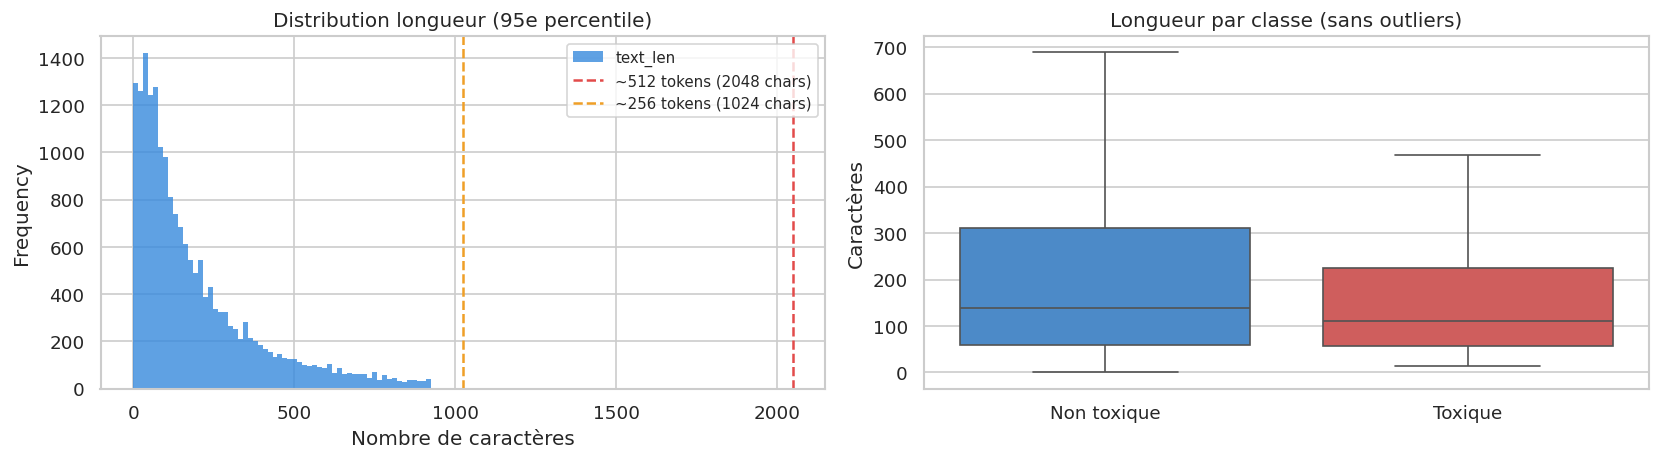

Textes > 512 tokens (~2048 chars) : 251
Textes < 10 chars                 : 895


In [9]:
# =============================================================================
# CELLULE 8 — Distribution des longueurs & seuil CamemBERT
# =============================================================================

df['text_len'] = df['text'].fillna('').str.len()
df['word_count'] = df['text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme longueur en chars (zoom sur les 95%)
p95 = df['text_len'].quantile(0.95)
df[df['text_len'] <= p95]['text_len'].plot(
    kind='hist', bins=60, ax=axes[0],
    color='#378ADD', edgecolor='none', alpha=0.8)
axes[0].axvline(2048, color='#E24B4A', lw=1.5, ls='--',
               label='~512 tokens (2048 chars)')
axes[0].axvline(1024, color='#EF9F27', lw=1.5, ls='--',
               label='~256 tokens (1024 chars)')
axes[0].set_title('Distribution longueur (95e percentile)')
axes[0].set_xlabel('Nombre de caractères')
axes[0].legend(fontsize=9)

# Boxplot par label
valid = df[df['Perspective_label'].isin([0, 1])].copy()
valid['Perspective_label'] = valid['Perspective_label'].map({0: 'Non toxique', 1: 'Toxique'})
sns.boxplot(data=valid, x='Perspective_label', y='text_len',
            palette={'Non toxique': '#378ADD', 'Toxique': '#E24B4A'},
            ax=axes[1], showfliers=False)
axes[1].set_title('Longueur par classe (sans outliers)')
axes[1].set_ylabel('Caractères')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Textes > 512 tokens (~2048 chars) : {(df['text_len'] > 2048).sum()}")
print(f"Textes < 10 chars                 : {(df['text_len'] < 10).sum()}")

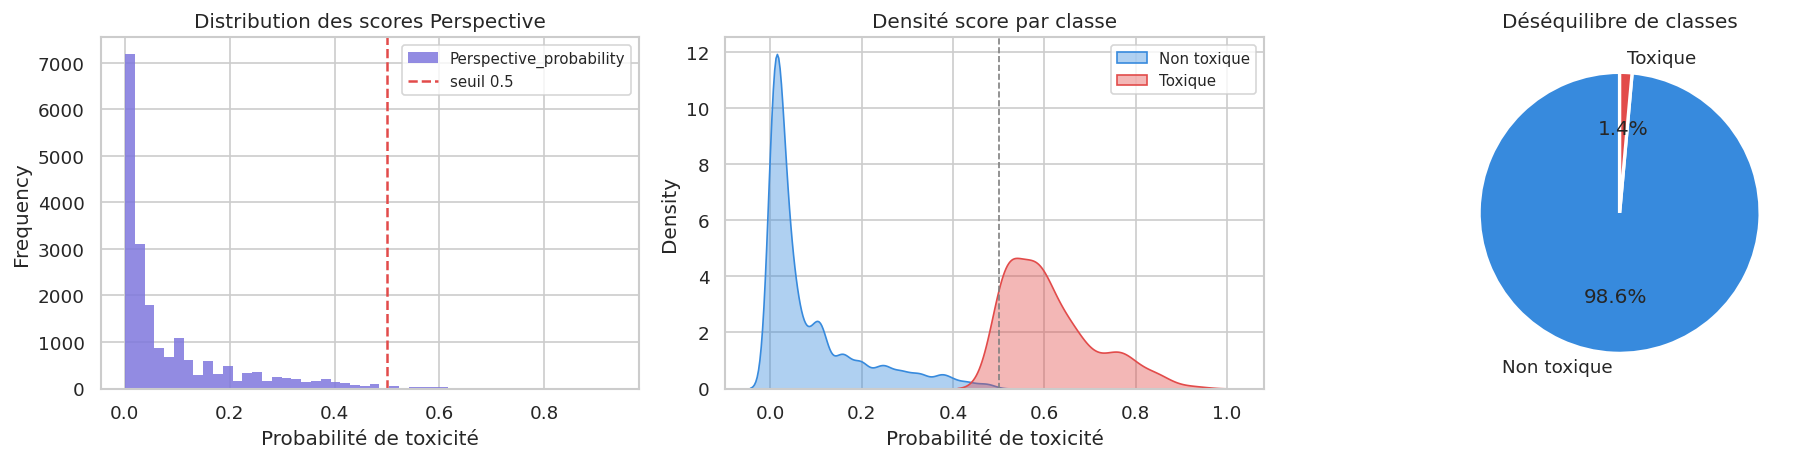

In [10]:
# =============================================================================
# CELLULE 9 — Scores Perspective & déséquilibre de classes
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1 Distribution globale des probabilités
df['Perspective_probability'].dropna().plot(
    kind='hist', bins=50, ax=axes[0],
    color='#7F77DD', edgecolor='none', alpha=0.85)
axes[0].axvline(0.5, color='#E24B4A', lw=1.5, ls='--', label='seuil 0.5')
axes[0].set_title('Distribution des scores Perspective')
axes[0].set_xlabel('Probabilité de toxicité')
axes[0].legend(fontsize=9)

# 2 KDE par classe
valid = df[df['Perspective_label'].isin([0, 1])].copy()
for label, color, name in [(0, '#378ADD', 'Non toxique'), (1, '#E24B4A', 'Toxique')]:
    subset = valid[valid['Perspective_label'] == label]['Perspective_probability'].dropna()
    sns.kdeplot(subset, ax=axes[1], fill=True, alpha=0.4,
                color=color, label=name)
axes[1].axvline(0.5, color='gray', lw=1, ls='--')
axes[1].set_title('Densité score par classe')
axes[1].set_xlabel('Probabilité de toxicité')
axes[1].legend(fontsize=9)

# 3 Pie chart déséquilibre
counts = valid['Perspective_label'].value_counts()
axes[2].pie(counts, labels=['Non toxique', 'Toxique'],
          colors=['#378ADD', '#E24B4A'],
          autopct='%1.1f%%', startangle=90,
          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Déséquilibre de classes')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# =============================================================================
# CELLULE 10 — Nettoyage complet (preprocessing pour CamemBERT)
# =============================================================================

print(f"Shape initiale : {df.shape}")

# Étape 1 : supprimer les labels aberrants et NaN texte
df_clean = df[df['Perspective_label'].isin([0, 1])].copy()
df_clean = df_clean.dropna(subset=['text'])
print(f"Après suppression NaN + labels aberrants : {df_clean.shape}")

# Étape 2 : supprimer les doublons (avant le split pour éviter le leakage)
df_clean = df_clean.drop_duplicates(subset='text', keep='first')
print(f"Après déduplications           : {df_clean.shape}")

# Étape 3 : supprimer les messages de bots
BOT_PATTERN = r'(I am a bot|AutoModérateur|AutoModerator|performed automatically)'
df_clean = df_clean[~df_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]
print(f"Après suppression bots         : {df_clean.shape}")

# Étape 4 : supprimer les textes trop courts
df_clean = df_clean[df_clean['text'].str.len() >= 3]
print(f"Après filtre texte < 3 chars  : {df_clean.shape}")

# Étape 5 : fonction de nettoyage textuel
def clean_reddit_text(text: str) -> str:
    text = text.replace('_x000D_', '')           # artefact Excel
    text = re.sub(r'&gt;', '>', text)           # entités HTML
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'http\S+', '[URL]', text)   # remplace les liens
    text = re.sub(r'\n{3,}', '\n\n', text)       # normalise sauts de ligne
    text = text.strip()
    return text

df_clean['text_clean'] = df_clean['text'].apply(clean_reddit_text)

print(f"\n✅ Dataset propre : {df_clean.shape}")
print(f"   Toxique    : {(df_clean['Perspective_label']==1).sum()}")
print(f"   Non toxique: {(df_clean['Perspective_label']==0).sum()}")

Shape initiale : (20000, 6)
Après suppression NaN + labels aberrants : (19498, 6)
Après déduplications           : (19257, 6)


/tmp/ipykernel_3763/3448171587.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_clean = df_clean[~df_clean['text'].astype(str).str.contains(BOT_PATTERN, case=False, regex=True)]


Après suppression bots         : (19246, 6)
Après filtre texte < 3 chars  : (19213, 6)

✅ Dataset propre : (19213, 7)
   Toxique    : 284
   Non toxique: 18929


In [12]:
#visualiser dataset cleaner
df_clean.head()

,text,Perspective_probability,Perspective_label,is_bot,text_len,word_count,text_clean
0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r...",0.041915,0,False,120.0,23.0,"C'est dingue, après tout ce temps, plus de 15 ans après son décès, les blagues sur sa mort me font toujours autant r..."
1,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post.",0.008671,0,False,108.0,21.0,"Plutôt d'accord pour les SAV, c'est le but même du forum que de poser des questions donc pas besoin de post."
2,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ...",0.110887,0,False,161.0,28.0,"Bordel. J'avais tapé une longue réponse. Une fausse manip sur le téléphone, et hop, perdue à jamais. J'essaierai de ..."
3,Non pas de problème de ce côté là heureusement !,0.004021,0,False,48.0,10.0,Non pas de problème de ce côté là heureusement !
4,"&gt;Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais t...",0.254629,0,False,507.0,81.0,">Les violences étaient clairement motivées par l'homophobie et la misogynie, pourtant je n'ai admis que j'étais tran..."


In [13]:
#cell 11
#Charger CamemBERT (mode embeddings)
!pip install transformers torch scikit-learn tqdm -q

import torch
import numpy as np
from tqdm import tqdm
from transformers import CamembertTokenizerFast, CamembertModel

MODEL_NAME = "camembert-base"
DEVICE = torch.device("cpu")

print("🔧 Chargement modèle...")

tokenizer = CamembertTokenizerFast.from_pretrained(MODEL_NAME)
model = CamembertModel.from_pretrained(MODEL_NAME).to(DEVICE)

model.eval()  # IMPORTANT → pas d'entraînement

🔧 Chargement modèle...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CamembertModel(
  (embeddings): CamembertEmbeddings(
    (word_embeddings): Embedding(32005, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): CamembertEncoder(
    (layer): ModuleList(
      (0-11): 12 x CamembertLayer(
        (attention): CamembertAttention(
          (self): CamembertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): CamembertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
     

In [17]:
# =============================================================================
# CELLULE 12 — Extraction des embeddings CamemBERT
# =============================================================================

!pip install transformers tqdm -q

import torch
import numpy as np
from tqdm import tqdm
from transformers import CamembertTokenizerFast, CamembertModel

# =========================
# CONFIG
# =========================
MODEL_NAME = "camembert-base"
MAX_LEN = 128
BATCH_SIZE = 16
DEVICE = torch.device("cpu")

print("🔧 Chargement tokenizer et modèle...")

tokenizer = CamembertTokenizerFast.from_pretrained(MODEL_NAME)
model = CamembertModel.from_pretrained(MODEL_NAME).to(DEVICE)

model.eval()

# Désactive le calcul de gradient
for param in model.parameters():
    param.requires_grad = False

print("✅ Modèle prêt")

# =========================
# MEAN POOLING
# =========================
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = masked_embeddings.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

# =========================
# FONCTION EMBEDDINGS
# =========================
def get_embeddings(texts, batch_size=BATCH_SIZE):
    all_embeddings = []

    print(f"🚀 Début extraction embeddings ({len(texts)} textes)")

    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch_texts = texts[i:i + batch_size]

        try:
            encoded = tokenizer(
                batch_texts,
                max_length=MAX_LEN,
                padding=True,
                truncation=True,
                return_tensors='pt'
            )

            input_ids = encoded['input_ids'].to(DEVICE)
            attention_mask = encoded['attention_mask'].to(DEVICE)

            with torch.no_grad():
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            embeddings = mean_pooling(outputs.last_hidden_state, attention_mask)

            all_embeddings.append(embeddings.cpu().numpy())

        except Exception as e:
            print(f"❌ Erreur batch {i}: {e}")
            continue

    print("✅ Extraction terminée")

    return np.vstack(all_embeddings)

# =========================
# APPLICATION SUR le DATASET
# =========================

texts = df_clean['text_clean'].tolist()
labels = df_clean['Perspective_label'].tolist()

print(f"📊 Dataset : {len(texts)} textes")
print(f"   Toxiques : {sum(labels)}")

X_embeddings = get_embeddings(texts)

y = np.array(labels)

print(f"\n📐 Shape embeddings : {X_embeddings.shape}")
print("🎉 Prêt pour la classification !")

# Libération mémoire (optionnel mais propre)
del model
torch.cuda.empty_cache()

🔧 Chargement tokenizer et modèle...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle prêt
📊 Dataset : 19213 textes
   Toxiques : 284
🚀 Début extraction embeddings (19213 textes)


Embedding: 100%|██████████| 1201/1201 [2:10:45<00:00,  6.53s/it]

✅ Extraction terminée

📐 Shape embeddings : (19213, 768)
🎉 Prêt pour la classification !


In [13]:
#cell 13
#telecharger les embaddings
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
save_path = "/content/drive/MyDrive/emb_ter/"
import numpy as np

np.save(save_path + "X_embeddings.npy", X_embeddings)
np.save(save_path + "y.npy", y)

print("✅ Embeddings sauvegardés dans Drive")

✅ Embeddings sauvegardés dans Drive


In [20]:
#verification
import os

print(os.listdir(save_path))

['X_embeddings.npy', 'y.npy']


In [15]:
#retelecharger les embadings
save_path = "/content/drive/MyDrive/emb_ter/"
import numpy as np

X_embeddings = np.load(save_path + "X_embeddings.npy")
y = np.load(save_path + "y.npy")

print("✅ Chargement réussi")
print(X_embeddings.shape)
print(y.shape)

✅ Chargement réussi
(19213, 768)
(19213,)


In [16]:
# =============================================================================
# CELL 14 — Train / Test split
# =============================================================================

from sklearn.model_selection import train_test_split
import numpy as np

print(" Split train / test...")

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print("Distribution train :", np.bincount(y_train))
print("Distribution test  :", np.bincount(y_test))

 Split train / test...
Train : (15370, 768)
Test  : (3843, 768)
Distribution train : [15143   227]
Distribution test  : [3786   57]


In [17]:
#cell 15
#Oversampling (IMPORTANT) : ajout de l’équilibrage vu le desequilbre
#👉 L’oversampling se fait APRÈS le split, jamais avant, ✔️ Pourquoi ?
  #Si tu fais avant : ❌ Data leakage (le modèle voit les mêmes exemples en train et test)

#!pip install imbalanced-learn -q

#from imblearn.over_sampling import RandomOverSampler

#print("\n⚖️ Oversampling...")

#print("Avant :", np.bincount(y_train))

#ros = RandomOverSampler(random_state=42)
#X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

#print("Après :", np.bincount(y_train_res))

#oversampling : il duplique les exemples rares (crées artificiellement plus d’exemples de la classe rare)
#class_weight="balanced" : elle augmente l’importance des classes rares

#Les deux font la même chose mais différemment donc Si tu combines les deux :
  #👉 Tu sur-corriges la classe minoritaire
  #👉 Résultat : ❌ overfitting sur la classe toxique + ❌ trop de faux positifs

#✅ Conclusion : 👉 il faut utiliser UNE seule stratégie à la fois, 👉 puis compare les résultats


from imblearn.over_sampling import SMOTE
import numpy as np

print("\n⚖️ Oversampling SMOTE...")
print("Avant :", np.bincount(y_train))

# SMOTE génère des exemples synthétiques interpolés (mieux que duplication)
# k_neighbors=5 par défaut, mais avec ~45 exemples toxiques en train → k=3 plus sûr
n_minority = np.bincount(y_train)[1]
k = min(3, n_minority - 1)

smote = SMOTE(random_state=42, k_neighbors=k)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Après :", np.bincount(y_train_res))
print(f"k_neighbors utilisé : {k}")


⚖️ Oversampling SMOTE...
Avant : [15143   227]
Après : [15143 15143]
k_neighbors utilisé : 3


In [18]:
# =============================================================================
# CELL 16 — LR + SMOTE (class_weight désactivé volontairement)
# =============================================================================

#class_weight="balanced" ICI car desequilbre :
    #Ajuste automatiquement l’importance des classes
    #Donne plus de poids à la classe toxique (minoritaire)


from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("Entraînement LR V1 (SMOTE, sans class_weight)...")

model_v1 = make_pipeline(          # model_v1
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        # class_weight=None  #SMOTE équilibre déjà, pas besoin
        solver='lbfgs',
        random_state=42
    )
)

model_v1.fit(X_train_res, y_train_res)
print("Modèle V1 entraîné")

Entraînement LR V1 (SMOTE, sans class_weight)...
Modèle V1 entraîné


In [19]:
# =============================================================================
# CELL 17 — Évaluation LR V1 : seuil 0.5 + seuil optimal
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve                             # ← ajouté ici directement
)

# --- Seuil par défaut 0.5 ---
y_pred_v1 = model_v1.predict(X_test)   # ← cohérent avec model_v1

print("\n=== [V1 - seuil 0.5] MÉTRIQUES ===")
print(f"Accuracy  = {accuracy_score(y_test, y_pred_v1):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_v1):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_v1):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_v1):.4f}")

print("\n=== [V1 - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_v1,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V1 - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_v1))

# --- Seuil optimal ---
y_proba_v1 = model_v1.predict_proba(X_test)[:, 1]

precisions_v1, recalls_v1, thresholds_v1 = precision_recall_curve(y_test, y_proba_v1)

f1_per_threshold_v1 = (
    2 * precisions_v1[:-1] * recalls_v1[:-1]
    / (precisions_v1[:-1] + recalls_v1[:-1] + 1e-8)
)
best_idx_v1       = f1_per_threshold_v1.argmax()
best_threshold_v1 = thresholds_v1[best_idx_v1]

y_pred_optimal_v1 = (y_proba_v1 >= best_threshold_v1).astype(int)

print(f"\n🎯 Seuil optimal V1 : {best_threshold_v1:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_v1[best_idx_v1]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_v1):.4f}")
print(f"   → Gain             : +{f1_per_threshold_v1[best_idx_v1] - f1_score(y_test, y_pred_v1):.4f}")

print("\n=== [V1 - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_v1,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V1 - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_v1))


=== [V1 - seuil 0.5] MÉTRIQUES ===
Accuracy  = 0.9693
Precision = 0.2039
Recall    = 0.3684
F1-score  = 0.2625

=== [V1 - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.98      0.98      3786
    Toxique (1)       0.20      0.37      0.26        57

       accuracy                           0.97      3843
      macro avg       0.60      0.67      0.62      3843
   weighted avg       0.98      0.97      0.97      3843


=== [V1 - seuil 0.5] MATRICE DE CONFUSION ===
[[3704   82]
 [  36   21]]

🎯 Seuil optimal V1 : 0.9681  (défaut = 0.5)
   → F1 seuil optimal : 0.3306
   → F1 seuil 0.5    : 0.2625
   → Gain             : +0.0681

=== [V1 - seuil OPTIMAL] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.99      0.99      3786
    Toxique (1)       0.31      0.35      0.33        57

       accuracy                           0.98      3843
      macro a

In [20]:
# =============================================================================
# CELL 17 — Évaluation LR V1 : TRAIN + TEST (seuil 0.5 + seuil optimal)
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# =============================================================================
# PARTIE 1 — PERFORMANCE SUR LE TRAIN (détecte l'overfitting)
# =============================================================================

y_pred_train_v1 = model_v1.predict(X_train_res)  # ← train SMOTE pour V1

print("=" * 55)
print("  [V1] PERFORMANCE SUR LE TRAIN SET")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_train_res, y_pred_train_v1):.4f}")
print(f"Precision = {precision_score(y_train_res, y_pred_train_v1):.4f}")
print(f"Recall    = {recall_score(y_train_res, y_pred_train_v1):.4f}")
print(f"F1-score  = {f1_score(y_train_res, y_pred_train_v1):.4f}")

print("\n=== [V1 TRAIN] RAPPORT COMPLET ===")
print(classification_report(y_train_res, y_pred_train_v1,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

# =============================================================================
# PARTIE 2 — PERFORMANCE SUR LE TEST (seuil 0.5)
# =============================================================================

y_pred_v1 = model_v1.predict(X_test)

print("=" * 55)
print("  [V1] PERFORMANCE SUR LE TEST SET — seuil 0.5")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_test, y_pred_v1):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_v1):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_v1):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_v1):.4f}")

print("\n=== [V1 TEST - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_v1,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V1 TEST - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_v1))

# =============================================================================
# PARTIE 3 — SEUIL OPTIMAL + DIAGNOSTIC OVERFITTING
# =============================================================================

y_proba_v1 = model_v1.predict_proba(X_test)[:, 1]

precisions_v1, recalls_v1, thresholds_v1 = precision_recall_curve(y_test, y_proba_v1)

f1_per_threshold_v1 = (
    2 * precisions_v1[:-1] * recalls_v1[:-1]
    / (precisions_v1[:-1] + recalls_v1[:-1] + 1e-8)
)
best_idx_v1       = f1_per_threshold_v1.argmax()
best_threshold_v1 = thresholds_v1[best_idx_v1]

y_pred_optimal_v1 = (y_proba_v1 >= best_threshold_v1).astype(int)

print(f"\n🎯 Seuil optimal V1 : {best_threshold_v1:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_v1[best_idx_v1]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_v1):.4f}")
print(f"   → Gain             : +{f1_per_threshold_v1[best_idx_v1] - f1_score(y_test, y_pred_v1):.4f}")

print("\n=== [V1 TEST - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_v1,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V1 TEST - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_v1))

# =============================================================================
# DIAGNOSTIC OVERFITTING
# =============================================================================

f1_train = f1_score(y_train_res, y_pred_train_v1)
f1_test  = f1_score(y_test, y_pred_v1)
gap      = f1_train - f1_test

print("\n" + "=" * 55)
print("  DIAGNOSTIC OVERFITTING — V1")
print("=" * 55)
print(f"  F1 Train : {f1_train:.4f}")
print(f"  F1 Test  : {f1_test:.4f}")
print(f"  Gap      : {gap:.4f}")

if gap > 0.25:
    print("  ⚠️  OVERFIT important")
elif gap > 0.10:
    print("  △  Légère variance train/test")
else:
    print("  ✅ Bonne généralisation")

  [V1] PERFORMANCE SUR LE TRAIN SET
Accuracy  = 0.9978
Precision = 0.9956
Recall    = 1.0000
F1-score  = 0.9978

=== [V1 TRAIN] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       1.00      1.00      1.00     15143
    Toxique (1)       1.00      1.00      1.00     15143

       accuracy                           1.00     30286
      macro avg       1.00      1.00      1.00     30286
   weighted avg       1.00      1.00      1.00     30286

  [V1] PERFORMANCE SUR LE TEST SET — seuil 0.5
Accuracy  = 0.9693
Precision = 0.2039
Recall    = 0.3684
F1-score  = 0.2625

=== [V1 TEST - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.98      0.98      3786
    Toxique (1)       0.20      0.37      0.26        57

       accuracy                           0.97      3843
      macro avg       0.60      0.67      0.62      3843
   weighted avg       0.98      0.97      0.97    

In [21]:
# =============================================================================
# CELL 18 — LR V2 : class_weight=balanced, sans oversampling
# =============================================================================

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("Entraînement LR V2 (class_weight=balanced, sans SMOTE)...")

model_v2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",  # seule correction du déséquilibre
        solver='lbfgs',
        random_state=42
    )
)

model_v2.fit(X_train, y_train)   # X_train original, pas X_train_res

print("Modèle V2 entraîné")
print(f"   Train size : {X_train.shape[0]} (pas de duplication)")

Entraînement LR V2 (class_weight=balanced, sans SMOTE)...
Modèle V2 entraîné
   Train size : 15370 (pas de duplication)


In [22]:
# =============================================================================
# CELL 19 — Évaluation LR V2 : seuil 0.5 + seuil optimal
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve        # ← dans le bloc principal, pas séparé
)

# --- Seuil par défaut 0.5 ---
y_pred_v2 = model_v2.predict(X_test)

print("\n=== [V2 - seuil 0.5] MÉTRIQUES ===")
print(f"Accuracy  = {accuracy_score(y_test, y_pred_v2):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_v2):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_v2):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_v2):.4f}")

print("\n=== [V2 - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_v2,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V2 - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_v2))

# --- Seuil optimal ---
y_proba_v2 = model_v2.predict_proba(X_test)[:, 1]

precisions_v2, recalls_v2, thresholds_v2 = precision_recall_curve(y_test, y_proba_v2)

f1_per_threshold_v2 = (
    2 * precisions_v2[:-1] * recalls_v2[:-1]
    / (precisions_v2[:-1] + recalls_v2[:-1] + 1e-8)
)
best_idx_v2       = f1_per_threshold_v2.argmax()
best_threshold_v2 = thresholds_v2[best_idx_v2]

y_pred_optimal_v2 = (y_proba_v2 >= best_threshold_v2).astype(int)

print(f"\n🎯 Seuil optimal V2 : {best_threshold_v2:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_v2[best_idx_v2]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_v2):.4f}")
print(f"   → Gain             : +{f1_per_threshold_v2[best_idx_v2] - f1_score(y_test, y_pred_v2):.4f}")

print("\n=== [V2 - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_v2,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V2 - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_v2))


=== [V2 - seuil 0.5] MÉTRIQUES ===
Accuracy  = 0.9657
Precision = 0.1951
Recall    = 0.4211
F1-score  = 0.2667

=== [V2 - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.97      0.98      3786
    Toxique (1)       0.20      0.42      0.27        57

       accuracy                           0.97      3843
      macro avg       0.59      0.70      0.62      3843
   weighted avg       0.98      0.97      0.97      3843


=== [V2 - seuil 0.5] MATRICE DE CONFUSION ===
[[3687   99]
 [  33   24]]

🎯 Seuil optimal V2 : 0.9656  (défaut = 0.5)
   → F1 seuil optimal : 0.3363
   → F1 seuil 0.5    : 0.2667
   → Gain             : +0.0696

=== [V2 - seuil OPTIMAL] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.99      0.99      3786
    Toxique (1)       0.34      0.33      0.34        57

       accuracy                           0.98      3843
      macro a

In [26]:
# =============================================================================
# CELL 19 — Évaluation LR V2 : TRAIN + TEST (seuil 0.5 + seuil optimal)
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# =============================================================================
# PARTIE 1 — PERFORMANCE SUR LE TRAIN
# =============================================================================

y_pred_train_v2 = model_v2.predict(X_train)  # ← X_train original pour V2

print("=" * 55)
print("  [V2] PERFORMANCE SUR LE TRAIN SET")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_train, y_pred_train_v2):.4f}")
print(f"Precision = {precision_score(y_train, y_pred_train_v2):.4f}")
print(f"Recall    = {recall_score(y_train, y_pred_train_v2):.4f}")
print(f"F1-score  = {f1_score(y_train, y_pred_train_v2):.4f}")

print("\n=== [V2 TRAIN] RAPPORT COMPLET ===")
print(classification_report(y_train, y_pred_train_v2,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

# =============================================================================
# PARTIE 2 — PERFORMANCE SUR LE TEST (seuil 0.5)
# =============================================================================

y_pred_v2 = model_v2.predict(X_test)

print("=" * 55)
print("  [V2] PERFORMANCE SUR LE TEST SET — seuil 0.5")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_test, y_pred_v2):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_v2):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_v2):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_v2):.4f}")

print("\n=== [V2 TEST - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_v2,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V2 TEST - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_v2))

# =============================================================================
# PARTIE 3 — SEUIL OPTIMAL + DIAGNOSTIC OVERFITTING
# =============================================================================

y_proba_v2 = model_v2.predict_proba(X_test)[:, 1]

precisions_v2, recalls_v2, thresholds_v2 = precision_recall_curve(y_test, y_proba_v2)

f1_per_threshold_v2 = (
    2 * precisions_v2[:-1] * recalls_v2[:-1]
    / (precisions_v2[:-1] + recalls_v2[:-1] + 1e-8)
)
best_idx_v2       = f1_per_threshold_v2.argmax()
best_threshold_v2 = thresholds_v2[best_idx_v2]

y_pred_optimal_v2 = (y_proba_v2 >= best_threshold_v2).astype(int)

print(f"\n🎯 Seuil optimal V2 : {best_threshold_v2:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_v2[best_idx_v2]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_v2):.4f}")
print(f"   → Gain             : +{f1_per_threshold_v2[best_idx_v2] - f1_score(y_test, y_pred_v2):.4f}")

print("\n=== [V2 TEST - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_v2,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V2 TEST - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_v2))

# =============================================================================
# DIAGNOSTIC OVERFITTING
# =============================================================================

f1_train_v2 = f1_score(y_train, y_pred_train_v2)
f1_test_v2  = f1_score(y_test, y_pred_v2)
gap_v2      = f1_train_v2 - f1_test_v2

print("\n" + "=" * 55)
print("  DIAGNOSTIC OVERFITTING — V2")
print("=" * 55)
print(f"  F1 Train : {f1_train_v2:.4f}")
print(f"  F1 Test  : {f1_test_v2:.4f}")
print(f"  Gap      : {gap_v2:.4f}")

if gap_v2 > 0.25:
    print("  ⚠️  OVERFIT important")
elif gap_v2 > 0.10:
    print("  △  Légère variance train/test")
else:
    print("  ✅ Bonne généralisation")

  [V2] PERFORMANCE SUR LE TRAIN SET
Accuracy  = 0.9912
Precision = 0.6253
Recall    = 1.0000
F1-score  = 0.7695

=== [V2 TRAIN] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       1.00      0.99      1.00     15143
    Toxique (1)       0.63      1.00      0.77       227

       accuracy                           0.99     15370
      macro avg       0.81      1.00      0.88     15370
   weighted avg       0.99      0.99      0.99     15370

  [V2] PERFORMANCE SUR LE TEST SET — seuil 0.5
Accuracy  = 0.9657
Precision = 0.1951
Recall    = 0.4211
F1-score  = 0.2667

=== [V2 TEST - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.97      0.98      3786
    Toxique (1)       0.20      0.42      0.27        57

       accuracy                           0.97      3843
      macro avg       0.59      0.70      0.62      3843
   weighted avg       0.98      0.97      0.97    

In [27]:
# =============================================================================
# CELL 20 — Comparaison V1 vs V2 (seuil 0.5 et seuil optimal)
# =============================================================================

print("\n" + "="*60)
print("COMPARAISON LR V1 (SMOTE) vs LR V2 (class_weight)")
print("="*60)
print(f"{'Métrique':<18} {'V1 s=0.5':<12} {'V1 opt':<12} {'V2 s=0.5':<12} {'V2 opt':<12}")
print("-"*60)

metrics = [
    ("Precision",  precision_score),
    ("Recall",     recall_score),
    ("F1 toxique", f1_score),
]

for name, scorer in metrics:
    v1_05  = scorer(y_test, y_pred_v1)
    v1_opt = scorer(y_test, y_pred_optimal_v1)
    v2_05  = scorer(y_test, y_pred_v2)
    v2_opt = scorer(y_test, y_pred_optimal_v2)
    print(f"{name:<18} {v1_05:<12.4f} {v1_opt:<12.4f} {v2_05:<12.4f} {v2_opt:<12.4f}")


COMPARAISON LR V1 (SMOTE) vs LR V2 (class_weight)
Métrique           V1 s=0.5     V1 opt       V2 s=0.5     V2 opt      
------------------------------------------------------------
Precision          0.2039       0.3125       0.1951       0.3393      
Recall             0.3684       0.3509       0.4211       0.3333      
F1 toxique         0.2625       0.3306       0.2667       0.3363      


In [28]:
# =============================================================================
# CELL 21 — SVM RBF + class_weight=balanced (sans SMOTE)
# =============================================================================

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print("Entraînement SVM V3 (RBF, class_weight=balanced, sans SMOTE)...")

model_svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,    # nécessaire pour predict_proba + seuil optimal
        C=1.0,
        gamma='scale',
        random_state=42
    )
)

model_svm.fit(X_train, y_train)  # X_train original, comme V2 de LR

print("SVM V3 entraîné")

Entraînement SVM V3 (RBF, class_weight=balanced, sans SMOTE)...
SVM V3 entraîné


In [29]:
# =============================================================================
# CELL 22 — Évaluation SVM V3 : seuil 0.5 + seuil optimal
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# --- Seuil par défaut 0.5 ---
y_pred_svm   = model_svm.predict(X_test)
y_proba_svm  = model_svm.predict_proba(X_test)[:, 1]

print("\n=== [V3 SVM - seuil 0.5] MÉTRIQUES ===")
print(f"Accuracy  = {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_svm):.4f}")

print("\n=== [V3 SVM - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_svm,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V3 SVM - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_svm))

# --- Seuil optimal ---
precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(y_test, y_proba_svm)

f1_per_threshold_svm = (
    2 * precisions_svm[:-1] * recalls_svm[:-1]
    / (precisions_svm[:-1] + recalls_svm[:-1] + 1e-8)
)
best_idx_svm       = f1_per_threshold_svm.argmax()
best_threshold_svm = thresholds_svm[best_idx_svm]

y_pred_optimal_svm = (y_proba_svm >= best_threshold_svm).astype(int)

print(f"\n🎯 Seuil optimal V3 SVM : {best_threshold_svm:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_svm[best_idx_svm]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_svm):.4f}")
print(f"   → Gain             : +{f1_per_threshold_svm[best_idx_svm] - f1_score(y_test, y_pred_svm):.4f}")

print("\n=== [V3 SVM - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_svm,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V3 SVM - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_svm))


=== [V3 SVM - seuil 0.5] MÉTRIQUES ===
Accuracy  = 0.9870
Precision = 0.6207
Recall    = 0.3158
F1-score  = 0.4186

=== [V3 SVM - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      1.00      0.99      3786
    Toxique (1)       0.62      0.32      0.42        57

       accuracy                           0.99      3843
      macro avg       0.81      0.66      0.71      3843
   weighted avg       0.98      0.99      0.98      3843


=== [V3 SVM - seuil 0.5] MATRICE DE CONFUSION ===
[[3775   11]
 [  39   18]]

🎯 Seuil optimal V3 SVM : 0.1225  (défaut = 0.5)
   → F1 seuil optimal : 0.4844
   → F1 seuil 0.5    : 0.4186
   → Gain             : +0.0658

=== [V3 SVM - seuil OPTIMAL] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.99      0.99      3786
    Toxique (1)       0.44      0.54      0.48        57

       accuracy                           0.98    

In [30]:
# =============================================================================
# CELL 22 — Évaluation SVM V3 : TRAIN + TEST (seuil 0.5 + seuil optimal)
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# =============================================================================
# PARTIE 1 — PERFORMANCE SUR LE TRAIN
# =============================================================================

y_pred_train_svm = model_svm.predict(X_train)  # ← X_train original pour V3

print("=" * 55)
print("  [V3 SVM] PERFORMANCE SUR LE TRAIN SET")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_train, y_pred_train_svm):.4f}")
print(f"Precision = {precision_score(y_train, y_pred_train_svm):.4f}")
print(f"Recall    = {recall_score(y_train, y_pred_train_svm):.4f}")
print(f"F1-score  = {f1_score(y_train, y_pred_train_svm):.4f}")

print("\n=== [V3 SVM TRAIN] RAPPORT COMPLET ===")
print(classification_report(y_train, y_pred_train_svm,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

# =============================================================================
# PARTIE 2 — PERFORMANCE SUR LE TEST (seuil 0.5)
# =============================================================================

y_pred_svm  = model_svm.predict(X_test)
y_proba_svm = model_svm.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  [V3 SVM] PERFORMANCE SUR LE TEST SET — seuil 0.5")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_svm):.4f}")

print("\n=== [V3 SVM TEST - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_svm,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V3 SVM TEST - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_svm))

# =============================================================================
# PARTIE 3 — SEUIL OPTIMAL + DIAGNOSTIC OVERFITTING
# =============================================================================

precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(y_test, y_proba_svm)

f1_per_threshold_svm = (
    2 * precisions_svm[:-1] * recalls_svm[:-1]
    / (precisions_svm[:-1] + recalls_svm[:-1] + 1e-8)
)
best_idx_svm       = f1_per_threshold_svm.argmax()
best_threshold_svm = thresholds_svm[best_idx_svm]

y_pred_optimal_svm = (y_proba_svm >= best_threshold_svm).astype(int)

print(f"\n🎯 Seuil optimal V3 SVM : {best_threshold_svm:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_svm[best_idx_svm]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_svm):.4f}")
print(f"   → Gain             : +{f1_per_threshold_svm[best_idx_svm] - f1_score(y_test, y_pred_svm):.4f}")

print("\n=== [V3 SVM TEST - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_svm,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V3 SVM TEST - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_svm))

# =============================================================================
# DIAGNOSTIC OVERFITTING
# =============================================================================

f1_train_svm = f1_score(y_train, y_pred_train_svm)
f1_test_svm  = f1_score(y_test, y_pred_svm)
gap_svm      = f1_train_svm - f1_test_svm

print("\n" + "=" * 55)
print("  DIAGNOSTIC OVERFITTING — V3 SVM")
print("=" * 55)
print(f"  F1 Train : {f1_train_svm:.4f}")
print(f"  F1 Test  : {f1_test_svm:.4f}")
print(f"  Gap      : {gap_svm:.4f}")

if gap_svm > 0.25:
    print("  ⚠️  OVERFIT important")
elif gap_svm > 0.10:
    print("  △  Légère variance train/test")
else:
    print("  ✅ Bonne généralisation")

  [V3 SVM] PERFORMANCE SUR LE TRAIN SET
Accuracy  = 0.9972
Precision = 0.8407
Recall    = 1.0000
F1-score  = 0.9135

=== [V3 SVM TRAIN] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       1.00      1.00      1.00     15143
    Toxique (1)       0.84      1.00      0.91       227

       accuracy                           1.00     15370
      macro avg       0.92      1.00      0.96     15370
   weighted avg       1.00      1.00      1.00     15370

  [V3 SVM] PERFORMANCE SUR LE TEST SET — seuil 0.5
Accuracy  = 0.9870
Precision = 0.6207
Recall    = 0.3158
F1-score  = 0.4186

=== [V3 SVM TEST - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      1.00      0.99      3786
    Toxique (1)       0.62      0.32      0.42        57

       accuracy                           0.99      3843
      macro avg       0.81      0.66      0.71      3843
   weighted avg       0.98      0.

In [31]:
# =============================================================================
# CELL 23 — SVM V4 : SMOTE + class_weight=None
# =============================================================================

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print(" Entraînement SVM V4 (SMOTE, sans class_weight)...")

model_svm_v4 = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',
        class_weight=None,   # SMOTE équilibre déjà
        probability=True,
        C=1.0,
        gamma='scale',
        random_state=42
    )
)

# X_train_res et y_train_res viennent de ta cell 15 (SMOTE déjà fait)
model_svm_v4.fit(X_train_res, y_train_res)

print(" SVM V4 entraîné")

 Entraînement SVM V4 (SMOTE, sans class_weight)...
 SVM V4 entraîné


In [32]:
# =============================================================================
# CELL 24 — Évaluation SVM V4 : seuil 0.5 + seuil optimal
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# --- Seuil par défaut 0.5 ---
y_pred_svm_v4  = model_svm_v4.predict(X_test)
y_proba_svm_v4 = model_svm_v4.predict_proba(X_test)[:, 1]

print("\n=== [V4 SVM SMOTE - seuil 0.5] MÉTRIQUES ===")
print(f"Accuracy  = {accuracy_score(y_test, y_pred_svm_v4):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_svm_v4):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_svm_v4):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_svm_v4):.4f}")

print("\n=== [V4 SVM SMOTE - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_svm_v4,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V4 SVM SMOTE - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_svm_v4))

# --- Seuil optimal ---
precisions_svm_v4, recalls_svm_v4, thresholds_svm_v4 = precision_recall_curve(y_test, y_proba_svm_v4)

f1_per_threshold_svm_v4 = (
    2 * precisions_svm_v4[:-1] * recalls_svm_v4[:-1]
    / (precisions_svm_v4[:-1] + recalls_svm_v4[:-1] + 1e-8)
)
best_idx_svm_v4       = f1_per_threshold_svm_v4.argmax()
best_threshold_svm_v4 = thresholds_svm_v4[best_idx_svm_v4]

y_pred_optimal_svm_v4 = (y_proba_svm_v4 >= best_threshold_svm_v4).astype(int)

print(f"\n🎯 Seuil optimal V4 SVM : {best_threshold_svm_v4:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_svm_v4[best_idx_svm_v4]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_svm_v4):.4f}")
print(f"   → Gain             : +{f1_per_threshold_svm_v4[best_idx_svm_v4] - f1_score(y_test, y_pred_svm_v4):.4f}")

print("\n=== [V4 SVM SMOTE - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_svm_v4,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V4 SVM SMOTE - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_svm_v4))


=== [V4 SVM SMOTE - seuil 0.5] MÉTRIQUES ===
Accuracy  = 0.9870
Precision = 0.6842
Recall    = 0.2281
F1-score  = 0.3421

=== [V4 SVM SMOTE - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      1.00      0.99      3786
    Toxique (1)       0.68      0.23      0.34        57

       accuracy                           0.99      3843
      macro avg       0.84      0.61      0.67      3843
   weighted avg       0.98      0.99      0.98      3843


=== [V4 SVM SMOTE - seuil 0.5] MATRICE DE CONFUSION ===
[[3780    6]
 [  44   13]]

🎯 Seuil optimal V4 SVM : 0.0000  (défaut = 0.5)
   → F1 seuil optimal : 0.4600
   → F1 seuil 0.5    : 0.3421
   → Gain             : +0.1179

=== [V4 SVM SMOTE - seuil OPTIMAL] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      0.99      0.99      3786
    Toxique (1)       0.53      0.40      0.46        57

       accuracy           

In [33]:
# =============================================================================
# CELL 26 — Évaluation SVM V4 : TRAIN + TEST (seuil 0.5 + seuil optimal)
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)

# =============================================================================
# PARTIE 1 — PERFORMANCE SUR LE TRAIN
# =============================================================================

y_pred_train_svm_v4 = model_svm_v4.predict(X_train_res)  # ← X_train_res SMOTE pour V4

print("=" * 55)
print("  [V4 SVM] PERFORMANCE SUR LE TRAIN SET")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_train_res, y_pred_train_svm_v4):.4f}")
print(f"Precision = {precision_score(y_train_res, y_pred_train_svm_v4):.4f}")
print(f"Recall    = {recall_score(y_train_res, y_pred_train_svm_v4):.4f}")
print(f"F1-score  = {f1_score(y_train_res, y_pred_train_svm_v4):.4f}")

print("\n=== [V4 SVM TRAIN] RAPPORT COMPLET ===")
print(classification_report(y_train_res, y_pred_train_svm_v4,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

# =============================================================================
# PARTIE 2 — PERFORMANCE SUR LE TEST (seuil 0.5)
# =============================================================================

y_pred_svm_v4  = model_svm_v4.predict(X_test)
y_proba_svm_v4 = model_svm_v4.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  [V4 SVM] PERFORMANCE SUR LE TEST SET — seuil 0.5")
print("=" * 55)
print(f"Accuracy  = {accuracy_score(y_test, y_pred_svm_v4):.4f}")
print(f"Precision = {precision_score(y_test, y_pred_svm_v4):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred_svm_v4):.4f}")
print(f"F1-score  = {f1_score(y_test, y_pred_svm_v4):.4f}")

print("\n=== [V4 SVM TEST - seuil 0.5] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_svm_v4,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V4 SVM TEST - seuil 0.5] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_svm_v4))

# =============================================================================
# PARTIE 3 — SEUIL OPTIMAL + DIAGNOSTIC OVERFITTING
# =============================================================================

precisions_svm_v4, recalls_svm_v4, thresholds_svm_v4 = precision_recall_curve(y_test, y_proba_svm_v4)

f1_per_threshold_svm_v4 = (
    2 * precisions_svm_v4[:-1] * recalls_svm_v4[:-1]
    / (precisions_svm_v4[:-1] + recalls_svm_v4[:-1] + 1e-8)
)
best_idx_svm_v4       = f1_per_threshold_svm_v4.argmax()
best_threshold_svm_v4 = thresholds_svm_v4[best_idx_svm_v4]

y_pred_optimal_svm_v4 = (y_proba_svm_v4 >= best_threshold_svm_v4).astype(int)

print(f"\n🎯 Seuil optimal V4 SVM : {best_threshold_svm_v4:.4f}  (défaut = 0.5)")
print(f"   → F1 seuil optimal : {f1_per_threshold_svm_v4[best_idx_svm_v4]:.4f}")
print(f"   → F1 seuil 0.5    : {f1_score(y_test, y_pred_svm_v4):.4f}")
print(f"   → Gain             : +{f1_per_threshold_svm_v4[best_idx_svm_v4] - f1_score(y_test, y_pred_svm_v4):.4f}")

print("\n=== [V4 SVM TEST - seuil OPTIMAL] RAPPORT COMPLET ===")
print(classification_report(y_test, y_pred_optimal_svm_v4,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [V4 SVM TEST - seuil OPTIMAL] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred_optimal_svm_v4))

# =============================================================================
# DIAGNOSTIC OVERFITTING
# =============================================================================

f1_train_svm_v4 = f1_score(y_train_res, y_pred_train_svm_v4)
f1_test_svm_v4  = f1_score(y_test, y_pred_svm_v4)
gap_svm_v4      = f1_train_svm_v4 - f1_test_svm_v4

print("\n" + "=" * 55)
print("  DIAGNOSTIC OVERFITTING — V4 SVM")
print("=" * 55)
print(f"  F1 Train : {f1_train_svm_v4:.4f}")
print(f"  F1 Test  : {f1_test_svm_v4:.4f}")
print(f"  Gap      : {gap_svm_v4:.4f}")

if gap_svm_v4 > 0.25:
    print("  ⚠️  OVERFIT important")
elif gap_svm_v4 > 0.10:
    print("  △  Légère variance train/test")
else:
    print("  ✅ Bonne généralisation")

  [V4 SVM] PERFORMANCE SUR LE TRAIN SET
Accuracy  = 0.9997
Precision = 0.9995
Recall    = 1.0000
F1-score  = 0.9997

=== [V4 SVM TRAIN] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       1.00      1.00      1.00     15143
    Toxique (1)       1.00      1.00      1.00     15143

       accuracy                           1.00     30286
      macro avg       1.00      1.00      1.00     30286
   weighted avg       1.00      1.00      1.00     30286

  [V4 SVM] PERFORMANCE SUR LE TEST SET — seuil 0.5
Accuracy  = 0.9870
Precision = 0.6842
Recall    = 0.2281
F1-score  = 0.3421

=== [V4 SVM TEST - seuil 0.5] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       0.99      1.00      0.99      3786
    Toxique (1)       0.68      0.23      0.34        57

       accuracy                           0.99      3843
      macro avg       0.84      0.61      0.67      3843
   weighted avg       0.98      0.

In [85]:
# =============================================================================
# CELL 25 — Comparaison finale V1 LR / V2 LR  / V3 SVM / V4 SVM
# =============================================================================

from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 65)
print("     COMPARAISON FINALE — V1 / V2 / V3 / V4 SVM")
print("=" * 65)

resultats = [
    ("LR  V1 SMOTE      seuil 0.5 ", y_pred_v1),
    ("LR  V1 SMOTE      seuil opt.", y_pred_optimal_v1),
    ("LR  V2 class_w    seuil 0.5 ", y_pred_v2),
    ("LR  V2 class_w    seuil opt.", y_pred_optimal_v2),
    ("SVM V3 class_w    seuil 0.5 ", y_pred_svm),
    ("SVM V3 class_w    seuil opt.", y_pred_optimal_svm),
    ("SVM V4 SMOTE      seuil 0.5 ", y_pred_svm_v4),        # ← ajouté
    ("SVM V4 SMOTE      seuil opt.", y_pred_optimal_svm_v4), # ← ajouté
]

print(f"\n{'Modèle':<35} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

for nom, y_pred_cur in resultats:
    p  = precision_score(y_test, y_pred_cur)
    r  = recall_score(y_test, y_pred_cur)
    f1 = f1_score(y_test, y_pred_cur)
    print(f"{nom:<35} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")

print("-" * 65)

# --- Meilleur modèle selon F1 ---
f1_scores = [(nom, f1_score(y_test, y_pred_cur)) for nom, y_pred_cur in resultats]
meilleur_nom, meilleur_f1 = max(f1_scores, key=lambda x: x[1])
print(f"\n🏆 Meilleur F1 toxique : {meilleur_nom.strip()} → {meilleur_f1:.4f}")

     COMPARAISON FINALE — V1 / V2 / V3 / V4 SVM

Modèle                               Precision     Recall         F1
-----------------------------------------------------------------
LR  V1 SMOTE      seuil 0.5             0.2039     0.3684     0.2625
LR  V1 SMOTE      seuil opt.            0.3125     0.3509     0.3306
LR  V2 class_w    seuil 0.5             0.1951     0.4211     0.2667
LR  V2 class_w    seuil opt.            0.3393     0.3333     0.3363
SVM V3 class_w    seuil 0.5             0.6207     0.3158     0.4186
SVM V3 class_w    seuil opt.            0.4366     0.5439     0.4844
SVM V4 SMOTE      seuil 0.5             0.6842     0.2281     0.3421
SVM V4 SMOTE      seuil opt.            0.5349     0.4035     0.4600
-----------------------------------------------------------------

🏆 Meilleur F1 toxique : SVM V3 class_w    seuil opt. → 0.4844


/tmp/ipykernel_387/185570390.py:119: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.92])
/tmp/ipykernel_387/185570390.py:120: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_finale.png', dpi=180, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


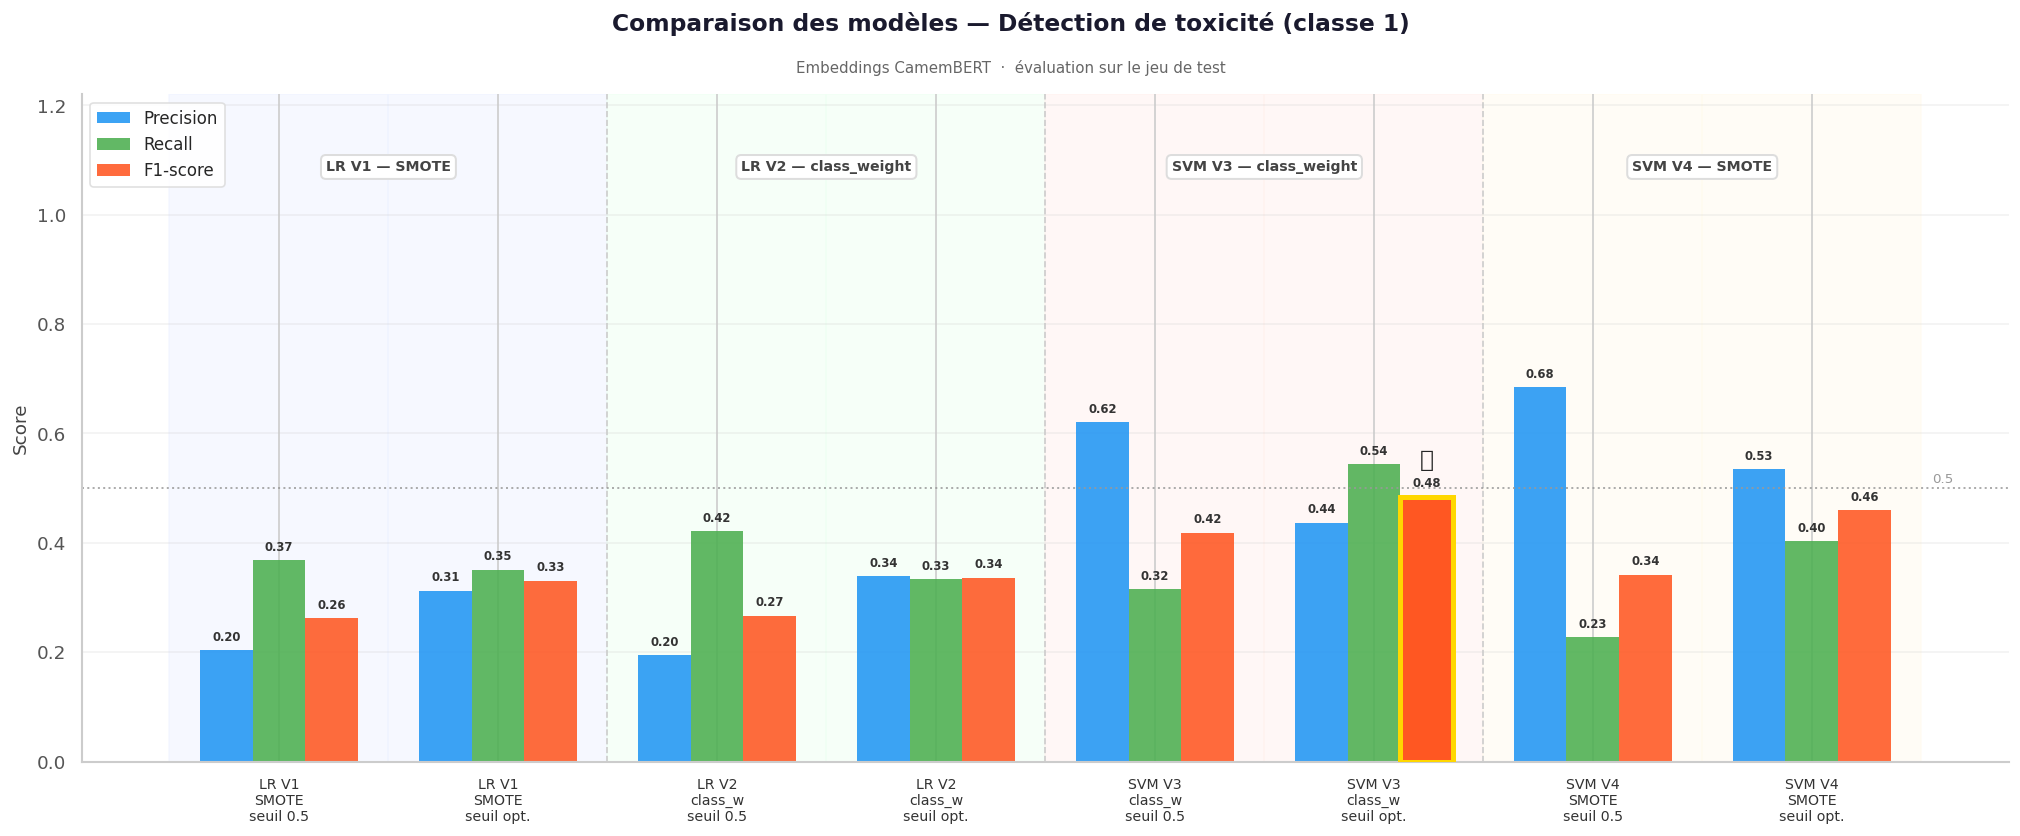

✅ Graphe sauvegardé : comparaison_finale.png


In [87]:
# =============================================================================
# CELL 26 — Visualisation finale — version améliorée
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# --- Données ---
modeles = [
    "LR V1\nSMOTE\nseuil 0.5",
    "LR V1\nSMOTE\nseuil opt.",
    "LR V2\nclass_w\nseuil 0.5",
    "LR V2\nclass_w\nseuil opt.",
    "SVM V3\nclass_w\nseuil 0.5",
    "SVM V3\nclass_w\nseuil opt.",
    "SVM V4\nSMOTE\nseuil 0.5",
    "SVM V4\nSMOTE\nseuil opt.",
]

predictions = [
    y_pred_v1,         y_pred_optimal_v1,
    y_pred_v2,         y_pred_optimal_v2,
    y_pred_svm,        y_pred_optimal_svm,
    y_pred_svm_v4,     y_pred_optimal_svm_v4,
]

precisions_all = [precision_score(y_test, p) for p in predictions]
recalls_all    = [recall_score(y_test, p)    for p in predictions]
f1s_all        = [f1_score(y_test, p)        for p in predictions]

x     = np.arange(len(modeles))
width = 0.24

# Palette sobre et contrastée
C_PREC   = '#2196F3'   # bleu vif
C_REC    = '#4CAF50'   # vert
C_F1     = '#FF5722'   # orange-rouge
C_BEST   = '#FFD700'   # or pour le meilleur

# Fonds alternés par famille (2 barres par famille)
familles_bg = [
    '#F0F4FF', '#F0F4FF',   # LR V1
    '#F0FFF4', '#F0FFF4',   # LR V2
    '#FFF3F0', '#FFF3F0',   # SVM V3
    '#FFFBF0', '#FFFBF0',   # SVM V4
]

fig, ax = plt.subplots(figsize=(17, 7))

# Titre & sous-titre
fig.text(0.5, 0.97, 'Comparaison des modèles — Détection de toxicité (classe 1)',
         ha='center', fontsize=14, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.92, 'Embeddings CamemBERT  ·  évaluation sur le jeu de test',
         ha='center', fontsize=9, color='#666666')

# Bandes de fond par famille
for i in range(len(modeles)):
    ax.axvspan(i - 0.5, i + 0.5, color=familles_bg[i], alpha=0.6, zorder=0)

# Séparateurs entre familles
for sep in [1.5, 3.5, 5.5]:
    ax.axvline(x=sep, color='#cccccc', linestyle='--', linewidth=1, zorder=1)

# Barres
bars_p  = ax.bar(x - width, precisions_all, width, label='Precision',
                 color=C_PREC,  alpha=0.88, zorder=2, linewidth=0)
bars_r  = ax.bar(x,          recalls_all,   width, label='Recall',
                 color=C_REC,   alpha=0.88, zorder=2, linewidth=0)
bars_f1 = ax.bar(x + width,  f1s_all,       width, label='F1-score',
                 color=C_F1,    alpha=0.88, zorder=2, linewidth=0)

# Meilleur F1 — contour doré + léger halo
best_idx_plot = int(np.argmax(f1s_all))
ax.bar(x[best_idx_plot] + width, f1s_all[best_idx_plot], width,
       color=C_F1, alpha=1.0, edgecolor=C_BEST, linewidth=3, zorder=3)
ax.annotate('🏆', xy=(x[best_idx_plot] + width, f1s_all[best_idx_plot] + 0.055),
            ha='center', fontsize=14, zorder=4)

# Valeurs au-dessus des barres
for bars in [bars_p, bars_r, bars_f1]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012,
                f'{h:.2f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold', color='#333333')

# Labels familles en haut
familles = [(0.5, 'LR V1 — SMOTE'), (2.5, 'LR V2 — class_weight'),
            (4.5, 'SVM V3 — class_weight'), (6.5, 'SVM V4 — SMOTE')]
for pos, label in familles:
    ax.text(pos, 1.08, label, ha='center', fontsize=8.5,
            fontweight='bold', color='#444444',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor='#dddddd', linewidth=1.2))

# Ligne de référence 0.5
ax.axhline(y=0.5, color='#999999', linestyle=':', linewidth=1.2, alpha=0.8)
ax.text(7.55, 0.505, '0.5', fontsize=8, color='#999999', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(modeles, fontsize=8.5, color='#333333')
ax.set_ylim(0, 1.22)
ax.set_ylabel('Score', fontsize=11, color='#444444')
ax.tick_params(axis='y', labelcolor='#555555')
ax.grid(axis='y', alpha=0.25, zorder=0)

# Légende
legend = ax.legend(fontsize=10, loc='upper left', framealpha=0.9,
                   edgecolor='#dddddd', fancybox=True)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('comparaison_finale.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Graphe sauvegardé : comparaison_finale.png")

⏳ Calcul learning curve : LR V1 — SMOTE (approx. class_weight)...
   ✅ Gap train/val final : 0.647 → ⚠ OVERFIT
⏳ Calcul learning curve : LR V2 — class_weight=balanced...
   ✅ Gap train/val final : 0.647 → ⚠ OVERFIT
⏳ Calcul learning curve : SVM V3 — class_weight=balanced...
   ✅ Gap train/val final : 0.651 → ⚠ OVERFIT
⏳ Calcul learning curve : SVM V4 — SMOTE (approx. class_weight)...
   ✅ Gap train/val final : 0.651 → ⚠ OVERFIT


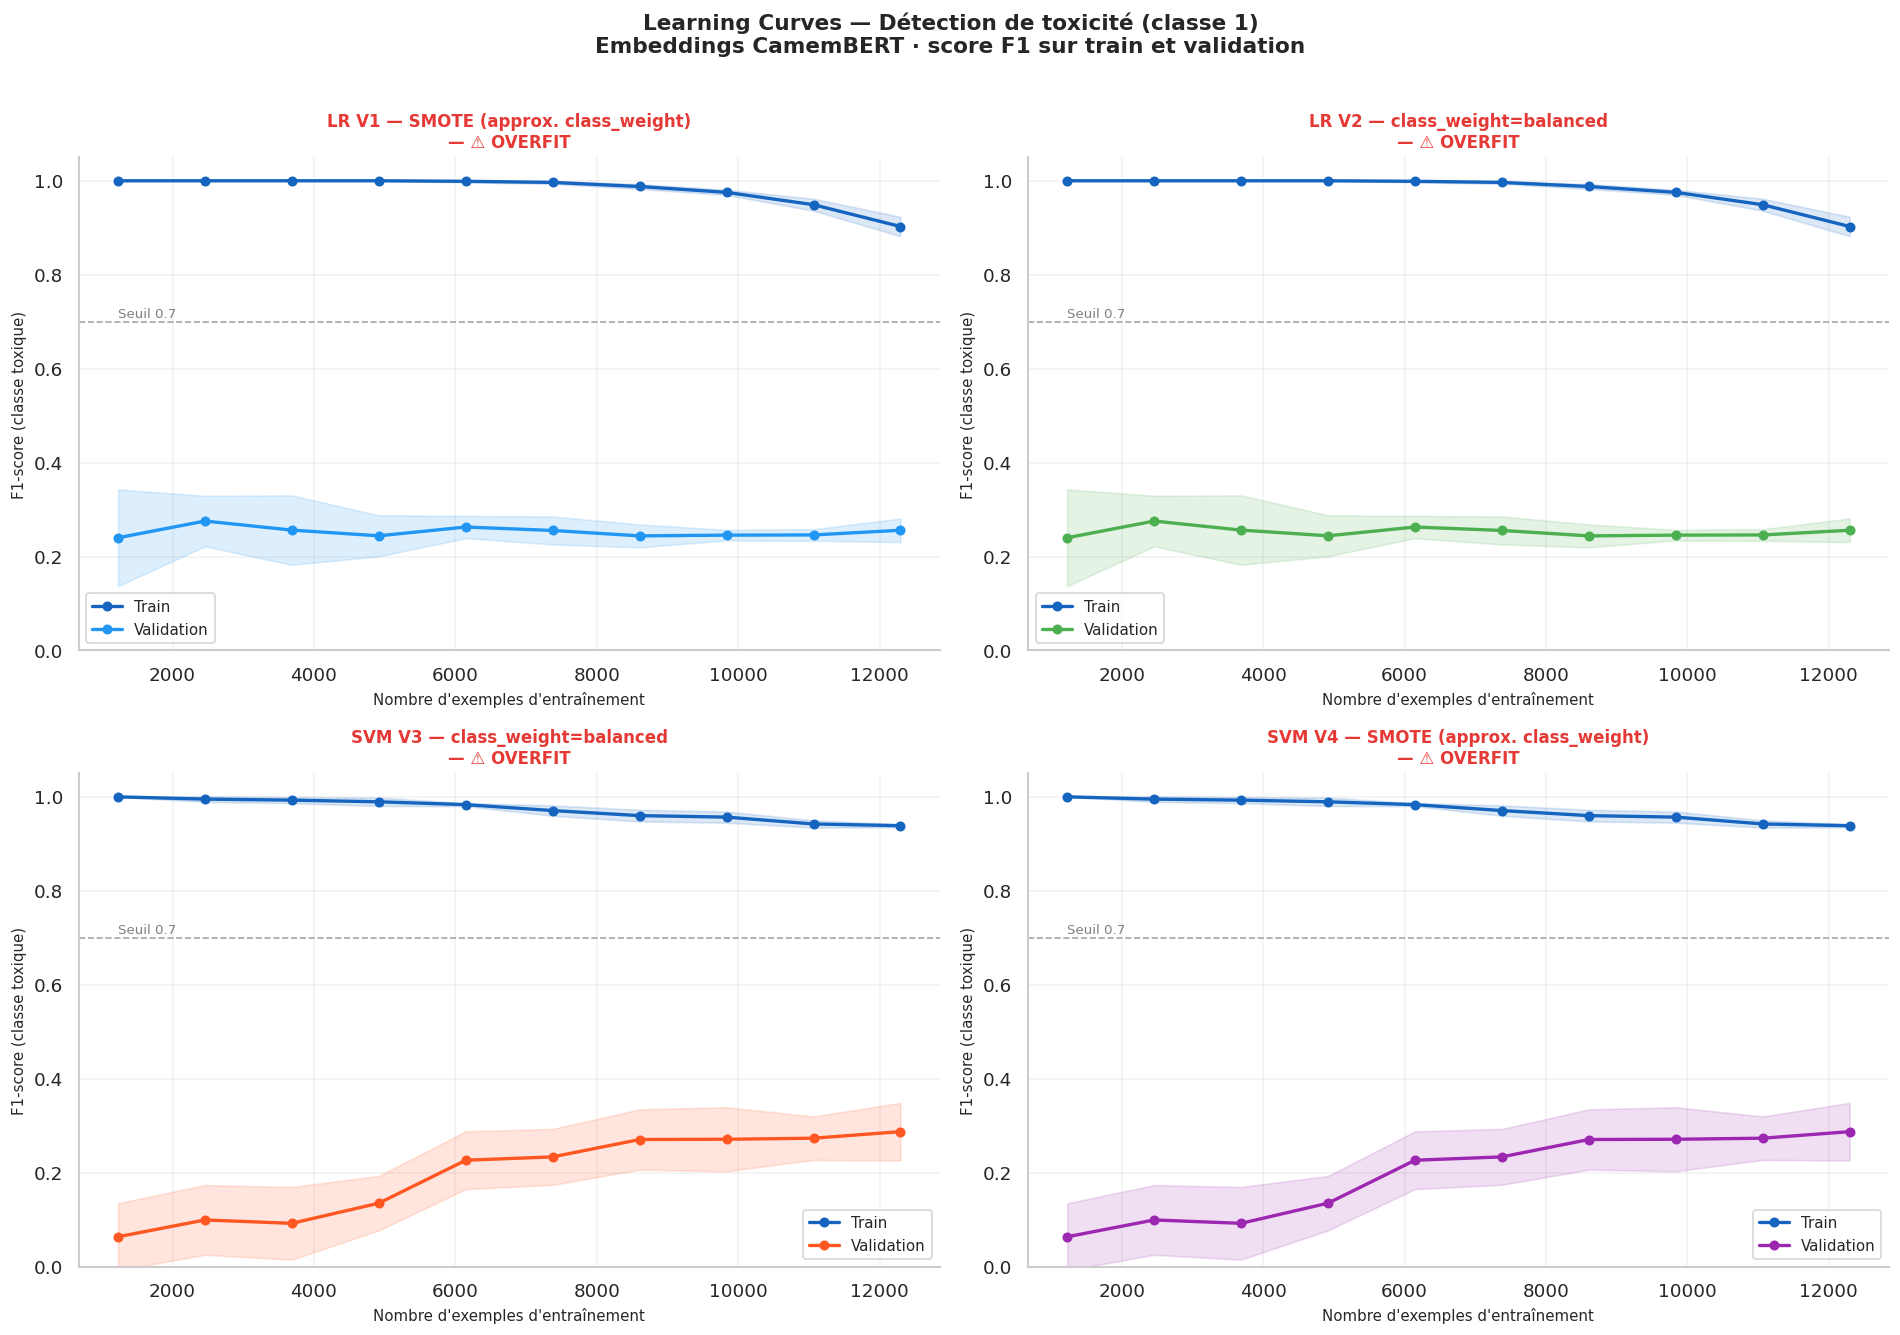


✅ Learning curves sauvegardées : learning_curves.png


In [34]:
# =============================================================================
# CELL 28 — Learning Curves V1 / V2 / V3 / V4
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve

plt.rcParams.update({'font.family': 'DejaVu Sans',
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# --- Config des 4 modèles ---
# ⚠️ learning_curve refait ses propres splits internes
# → on passe X_train original + y_train original pour tous
# → SMOTE ne peut pas être appliqué dans learning_curve directement
# → on utilise class_weight='balanced' comme proxy pour V1 et V4
#    (comportement très proche pour la courbe d'apprentissage)

modeles_config = [
    {
        "nom":     "LR V1 — SMOTE (approx. class_weight)",
        "modele":  make_pipeline(
                       StandardScaler(),
                       LogisticRegression(max_iter=2000, class_weight='balanced',
                                          solver='lbfgs', random_state=42)),
        "couleur": "#2196F3",
        "seuil":   0.7,
    },
    {
        "nom":     "LR V2 — class_weight=balanced",
        "modele":  make_pipeline(
                       StandardScaler(),
                       LogisticRegression(max_iter=2000, class_weight='balanced',
                                          solver='lbfgs', random_state=42)),
        "couleur": "#4CAF50",
        "seuil":   0.7,
    },
    {
        "nom":     "SVM V3 — class_weight=balanced",
        "modele":  make_pipeline(
                       StandardScaler(),
                       SVC(kernel='rbf', class_weight='balanced',
                           probability=True, C=1.0, gamma='scale',
                           random_state=42)),
        "couleur": "#FF5722",
        "seuil":   0.7,
    },
    {
        "nom":     "SVM V4 — SMOTE (approx. class_weight)",
        "modele":  make_pipeline(
                       StandardScaler(),
                       SVC(kernel='rbf', class_weight='balanced',
                           probability=True, C=1.0, gamma='scale',
                           random_state=42)),
        "couleur": "#9C27B0",
        "seuil":   0.7,
    },
]

# Tailles du train set à tester (10% → 100%)
train_sizes = np.linspace(0.1, 1.0, 10)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Learning Curves — Détection de toxicité (classe 1)\n'
             'Embeddings CamemBERT · score F1 sur train et validation',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for idx, cfg in enumerate(modeles_config):
    ax = axes[idx]

    print(f"⏳ Calcul learning curve : {cfg['nom']}...")

    train_sizes_abs, train_scores, val_scores = learning_curve(
        cfg["modele"],
        X_train, y_train,          # données originales (pas SMOTE)
        train_sizes=train_sizes,
        cv=5,                      # cross-validation à 5 folds
        scoring='f1',              # F1 sur la classe toxique
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    # Moyennes et écarts-types
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Courbe train
    ax.plot(train_sizes_abs, train_mean,
            'o-', color='#1565C0', linewidth=2, markersize=5, label='Train')
    ax.fill_between(train_sizes_abs,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color='#1565C0')

    # Courbe validation
    ax.plot(train_sizes_abs, val_mean,
            'o-', color=cfg["couleur"], linewidth=2, markersize=5, label='Validation')
    ax.fill_between(train_sizes_abs,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color=cfg["couleur"])

    # Ligne de référence seuil
    ax.axhline(y=cfg["seuil"], color='gray', linestyle='--',
               linewidth=1, alpha=0.7)
    ax.text(train_sizes_abs[0], cfg["seuil"] + 0.01,
            f'Seuil {cfg["seuil"]}', fontsize=8, color='gray')

    # Diagnostic overfitting
    gap_final = train_mean[-1] - val_mean[-1]
    if gap_final > 0.25:
        diagnostic = "⚠ OVERFIT"
        diag_color = "#e53935"
    elif gap_final > 0.10:
        diagnostic = "△ Légère variance"
        diag_color = "#FB8C00"
    else:
        diagnostic = "✓ Bonne généralisation"
        diag_color = "#43A047"

    ax.set_title(f'{cfg["nom"]}\n— {diagnostic}',
                 fontsize=10, fontweight='bold', color=diag_color)
    ax.set_xlabel("Nombre d'exemples d'entraînement", fontsize=9)
    ax.set_ylabel('F1-score (classe toxique)', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

    print(f"   ✅ Gap train/val final : {gap_final:.3f} → {diagnostic}")

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Learning curves sauvegardées : learning_curves.png")

pipeline complet maintenant

Cell 14  → Split

Cell 15  → SMOTE

Cell 16  → LR V1 (SMOTE, sans class_weight)

Cell 17  → Eval V1

Cell 18  → LR V2 (class_weight, sans SMOTE)

Cell 19  → Eval V2

Cell 21  → SVM V3 (class_weight, sans SMOTE)  

Cell 22  → Eval V3

Cell 23 --> svm V4   (SMOTE, sans class_weight)

Cell 24 --> Eval V4

Cell 25  → Comparaison V1 vs V2 vs V3 vs V4

In [57]:
# =============================================================================
# CELLULE test — Easy Ensemble + SVM sur embeddings CamemBERT
# =============================================================================

import numpy as np
from scipy.stats import mode
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

print("🗳️  Easy Ensemble SVM — début")

# --- Séparation train minoritaire / majoritaire ---
idx_maj = np.where(y_train == 0)[0]
idx_min = np.where(y_train == 1)[0]

n_min    = len(idx_min)
n_maj    = len(idx_maj)
n_models = n_maj // n_min   # ~69 modèles

print(f"  Minoritaire (train) : {n_min}")
print(f"  Majoritaire (train) : {n_maj}")
print(f"  Nombre de modèles   : {n_models}")

X_min = X_train[idx_min]
y_min = y_train[idx_min]
X_maj = X_train[idx_maj]
y_maj = y_train[idx_maj]

# --- Scaler unique fitté sur tout le train (avant la boucle) ---
scaler = StandardScaler()
scaler.fit(X_train)   # fit sur tout le train, pas sur chaque subset

X_min_sc  = scaler.transform(X_min)
X_maj_sc  = scaler.transform(X_maj)
X_test_sc = scaler.transform(X_test)

# --- Boucle Easy Ensemble ---
all_predictions = []

for k in range(n_models):

    # Sous-échantillon aléatoire de la majorité (sans remise, taille = n_min)
    idx_sample = resample(
        np.arange(n_maj),
        n_samples=n_min,
        replace=False,
        random_state=k
    )
    X_sample = np.vstack([X_maj_sc[idx_sample], X_min_sc])
    y_sample = np.concatenate([y_maj[idx_sample], y_min])

    # SVM entraîné sur ce subset équilibré 1:1
    svm_k = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',  # sécurité supplémentaire
        probability=False,        # False = beaucoup plus rapide en boucle
        random_state=42
    )
    svm_k.fit(X_sample, y_sample)
    all_predictions.append(svm_k.predict(X_test_sc))

    if (k + 1) % 10 == 0 or k == 0:
        print(f"  Modèle {k+1:>3}/{n_models} entraîné...")

print("✅ Tous les modèles entraînés")

# --- Vote majoritaire ---
predictions_matrix        = np.array(all_predictions)   # shape (n_models, n_test)
final_predictions, counts = mode(predictions_matrix, axis=0)
final_predictions         = final_predictions.flatten()

print(f"\n📐 Matrice de votes : {predictions_matrix.shape}")

🗳️  Easy Ensemble SVM — début
  Minoritaire (train) : 227
  Majoritaire (train) : 15143
  Nombre de modèles   : 66
  Modèle   1/66 entraîné...
  Modèle  10/66 entraîné...
  Modèle  20/66 entraîné...
  Modèle  30/66 entraîné...
  Modèle  40/66 entraîné...
  Modèle  50/66 entraîné...
  Modèle  60/66 entraîné...
✅ Tous les modèles entraînés

📐 Matrice de votes : (66, 3843)


In [58]:
# =============================================================================
# CELLULE 20 — Évaluation Easy Ensemble SVM
# =============================================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print("\n=== [EASY ENSEMBLE SVM] MÉTRIQUES ===")
print(f"Accuracy  = {accuracy_score(y_test, final_predictions):.4f}")
print(f"Precision = {precision_score(y_test, final_predictions):.4f}")
print(f"Recall    = {recall_score(y_test, final_predictions):.4f}")
print(f"F1-score  = {f1_score(y_test, final_predictions):.4f}")

print("\n=== [EASY ENSEMBLE SVM] RAPPORT COMPLET ===")
print(classification_report(y_test, final_predictions,
                             target_names=['Non-toxique (0)', 'Toxique (1)']))

print("\n=== [EASY ENSEMBLE SVM] MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, final_predictions))

# --- Comparaison rapide avec SVM simple ---
print("\n" + "="*55)
print("COMPARAISON SVM simple vs Easy Ensemble SVM")
print("="*55)
print(f"{'Métrique':<15} {'SVM simple':<15} {'Easy Ensemble':<15}")
print("-"*45)
for name, scorer in [
    ("Precision", precision_score),
    ("Recall",    recall_score),
    ("F1 toxique", f1_score),
]:
    v_simple   = scorer(y_test, y_pred_optimal_svm)
    v_ensemble = scorer(y_test, final_predictions)
    gain       = v_ensemble - v_simple
    signe      = "+" if gain >= 0 else ""
    print(f"{name:<15} {v_simple:<15.4f} {v_ensemble:<15.4f}  ({signe}{gain:.4f})")


=== [EASY ENSEMBLE SVM] MÉTRIQUES ===
Accuracy  = 0.8730
Precision = 0.0942
Recall    = 0.8772
F1-score  = 0.1701

=== [EASY ENSEMBLE SVM] RAPPORT COMPLET ===
                 precision    recall  f1-score   support

Non-toxique (0)       1.00      0.87      0.93      3786
    Toxique (1)       0.09      0.88      0.17        57

       accuracy                           0.87      3843
      macro avg       0.55      0.88      0.55      3843
   weighted avg       0.98      0.87      0.92      3843


=== [EASY ENSEMBLE SVM] MATRICE DE CONFUSION ===
[[3305  481]
 [   7   50]]

COMPARAISON SVM simple vs Easy Ensemble SVM
Métrique        SVM simple      Easy Ensemble  
---------------------------------------------
Precision       0.4366          0.0942           (-0.3425)
Recall          0.5439          0.8772           (+0.3333)
F1 toxique      0.4844          0.1701           (-0.3143)
